# Project 1 — Feature Engineering for Tabular Prediction

Feature engineering is the process of turning raw columns into representations that make useful patterns easier for a model to learn. In tabular machine learning, this is often as important as the choice of algorithm itself. A model never sees “reality” directly; it sees numbers produced by our preprocessing decisions. Encoding a categorical variable, scaling a continuous variable, compressing a skewed variable, or adding an interaction can change what the model is able to express.

This project uses the Adult Income dataset, a realistic mixed-type tabular dataset with numerical and categorical variables. The task is to predict whether a person’s income exceeds a threshold using demographic and employment-related attributes. The main focus is not only classification performance, but also how representation choices influence model behavior, dimensionality, interpretability, and leakage risk.

## Prerequisites

The notebook assumes comfort with pandas, NumPy, train/test splits, and basic classification. It also uses scikit-learn pipelines, so it helps to know that a pipeline chains preprocessing and modeling steps into one object. Metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices are used to compare models from different perspectives.

## Problem statement

Given demographic and employment-related attributes, predict whether a person’s income exceeds a specified threshold.

This is a representation problem as much as a prediction problem. Several columns are categorical labels, some numerical variables are highly skewed, some features are redundant, and some variables may interact with one another. A linear classifier, a nearest-neighbor model, and a tree ensemble will not respond to these representations in the same way.

## Dataset description and source

The Adult Income dataset is loaded directly from OpenML using `fetch_openml`. It contains columns such as age, workclass, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country, and income.

The dataset is useful for feature engineering because it combines continuous variables, nominal categorical variables, ordered or partially ordered variables, sparse high-cardinality categories, and heavily skewed financial variables. Some versions of the dataset use `?` as a missing-value marker; the notebook converts this marker to missing values before modeling.

A caution is important: this dataset contains sensitive demographic variables. The goal here is educational, not to claim that income prediction from personal attributes is ethically neutral. Later sections discuss limitations, bias, and interpretation.

In [1]:
# Optional installation cell. Run only if your environment misses these packages.
# !pip install -U scikit-learn pandas numpy matplotlib seaborn openml

## Load libraries

The notebook uses scikit-learn pipelines and `ColumnTransformer` so that transformations are learned only from the training data. This is essential because preprocessing steps such as imputation, scaling, frequency encoding, and target encoding can leak information if fitted on the full dataset before splitting.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## Load the Adult Income dataset

The dataset is fetched inside the notebook so that no local CSV file is required. The target labels are converted to a binary variable: `1` for income above the threshold and `0` otherwise. The cleaning step standardizes string values and treats `?` as a missing marker.

In [3]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
X = adult.data.copy()
y_raw = adult.target.copy()

X = X.replace("?", np.nan)
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("object").str.strip()

y = y_raw.astype(str).str.strip().str.replace(".", "", regex=False)
y = y.map({">50K": 1, "<=50K": 0}).astype(int)

print("Shape:", X.shape)
print("Target counts:")
display(y.value_counts().rename(index={0: "<=50K", 1: ">50K"}).to_frame("count"))
display(X.head())

Shape: (48842, 14)
Target counts:


,count
<=50K,37155
>50K,11687


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States
4,18.0,NaN,103497.0,Some-college,10.0,Never-married,NaN,Own-child,White,Female,0.0,0.0,30.0,United-States


## Initial data inspection

Raw tabular data often mixes continuous variables, discrete counts, nominal categories, and ordered categories. Before creating features, we need to know which columns are numerical, which are categorical, where missing values occur, and whether any categorical variables have many distinct levels.

In [4]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

inspection = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_%": (X.isna().mean() * 100).round(2),
    "n_unique": X.nunique(dropna=True)
}).sort_values(["dtype", "n_unique"], ascending=[True, False])

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
display(inspection)

Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


,dtype,missing,missing_%,n_unique
fnlwgt,float64,0,0.00,28523
capital-gain,float64,0,0.00,123
capital-loss,float64,0,0.00,99
hours-per-week,float64,0,0.00,96
age,float64,0,0.00,74
education-num,float64,0,0.00,16
native-country,object,857,1.75,41
education,object,0,0.00,16
occupation,object,2809,5.75,14
workclass,object,2799,5.73,8


## Exploratory data analysis as feature-engineering evidence

EDA is not only for making plots. It tells us which variables may need scaling, which may need nonlinear transformation, which categorical variables can explode under one-hot encoding, and which rare categories might make estimates unstable. These observations become design choices in the modeling pipeline.

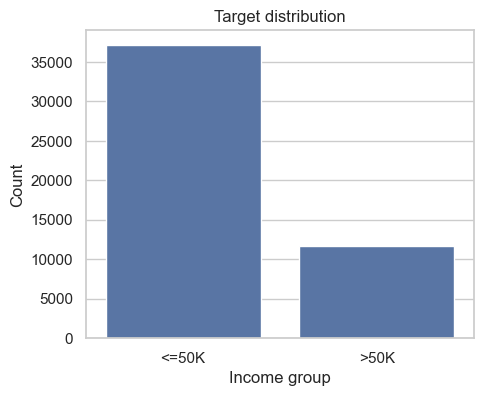

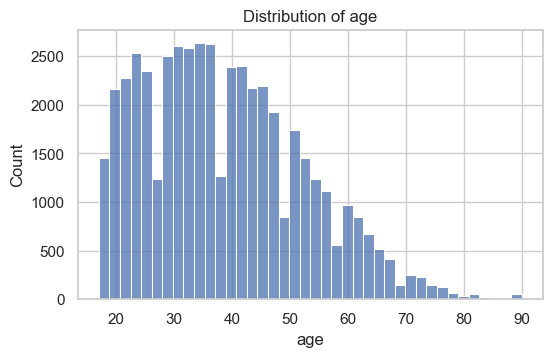

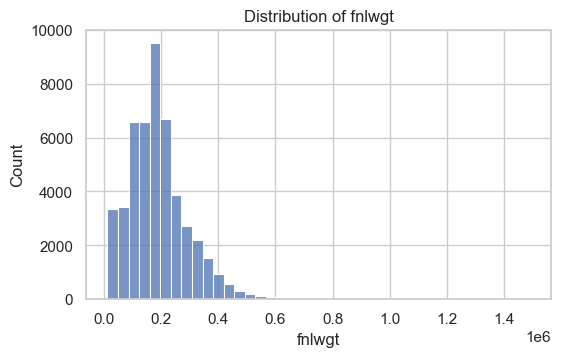

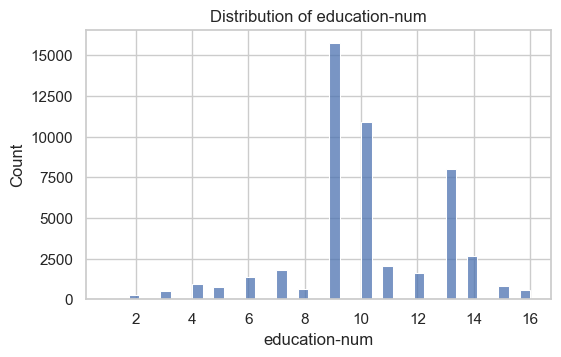

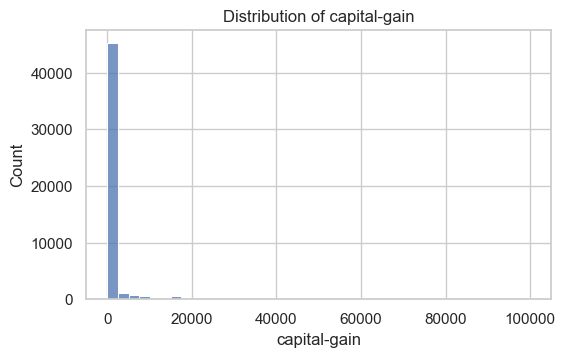

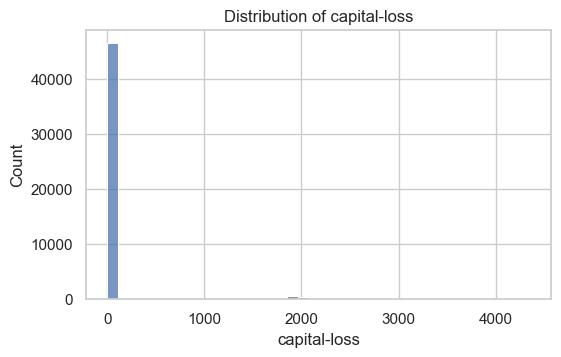

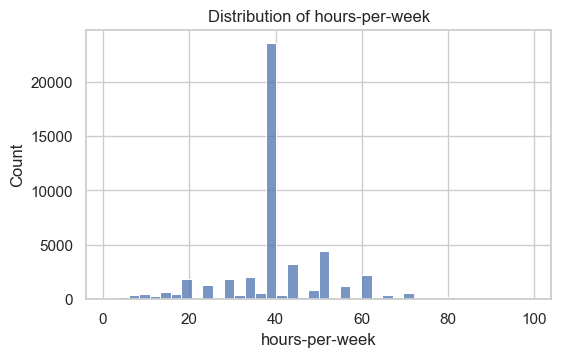

,number_of_categories
native-country,41
education,16
occupation,14
workclass,8
marital-status,7
relationship,6
race,5
sex,2


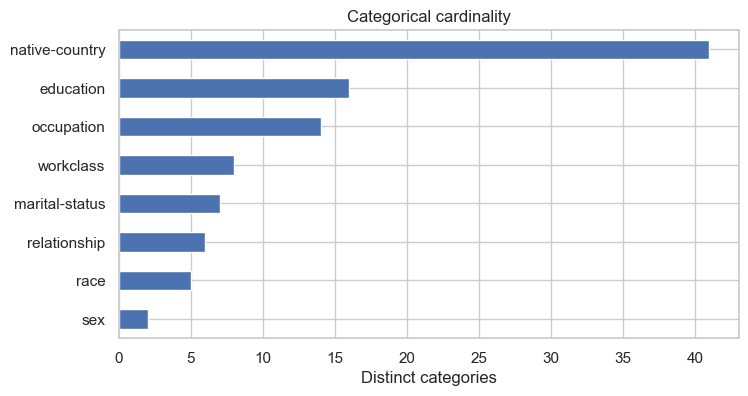

,skewness
capital-gain,11.894659
capital-loss,4.569809
fnlwgt,1.438892
age,0.557580
education-num,-0.316525
hours-per-week,0.238750


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y.map({0: "<=50K", 1: ">50K"}), ax=ax)
ax.set_title("Target distribution")
ax.set_xlabel("Income group")
ax.set_ylabel("Count")
plt.show()

plot_cols = [c for c in ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"] if c in X.columns]
for col in plot_cols:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.histplot(X[col].dropna(), bins=40, kde=False, ax=ax)
    ax.set_title(f"Distribution of {col}")
    plt.show()

cardinality = X[cat_cols].nunique(dropna=True).sort_values(ascending=False)
display(cardinality.to_frame("number_of_categories"))

fig, ax = plt.subplots(figsize=(8, 4))
cardinality.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Categorical cardinality")
ax.set_xlabel("Distinct categories")
plt.show()

skewness = X[num_cols].skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
display(skewness.to_frame("skewness"))

### Class-wise views of selected variables

When the distribution of a feature differs by target class, the feature may contain predictive information. This does not mean the relationship is causal; it only suggests that the variable may help the model separate the classes.

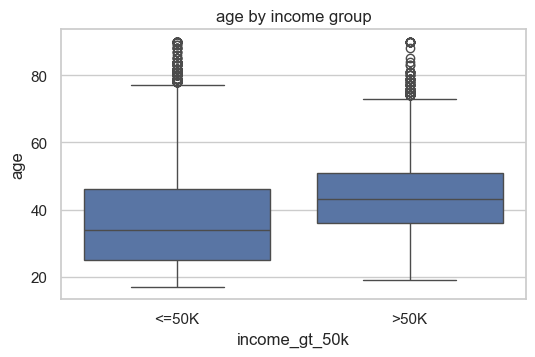

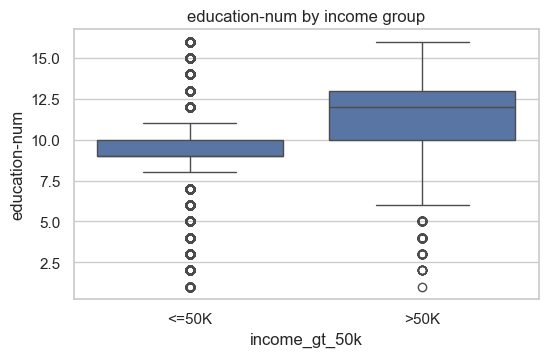

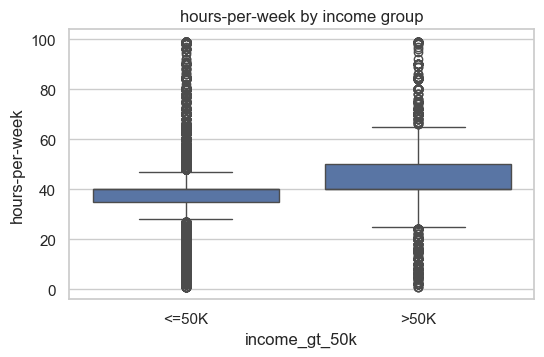

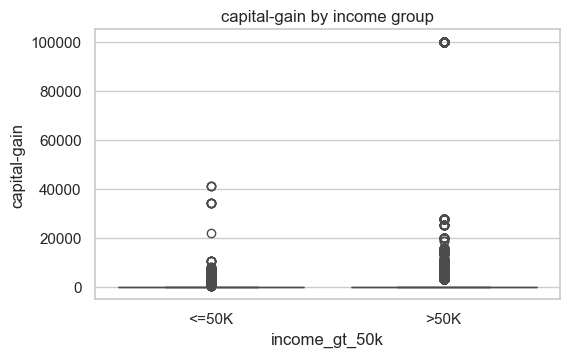

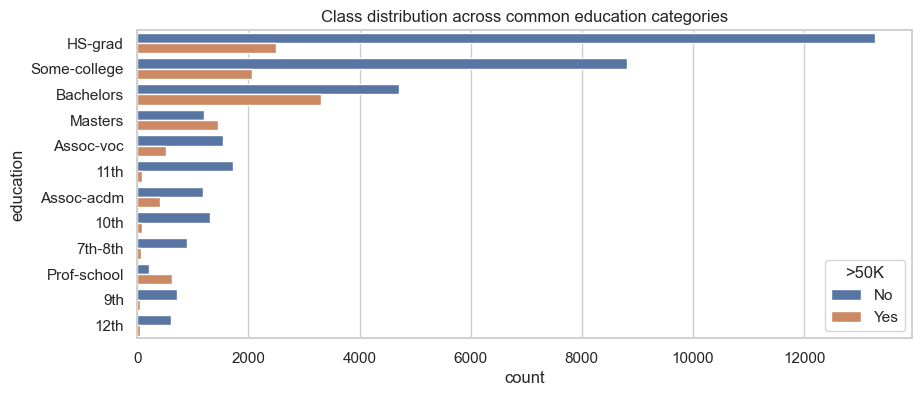

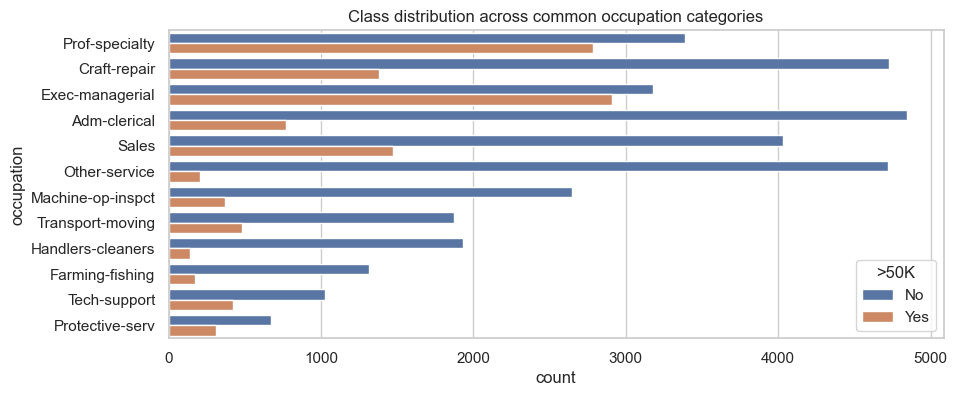

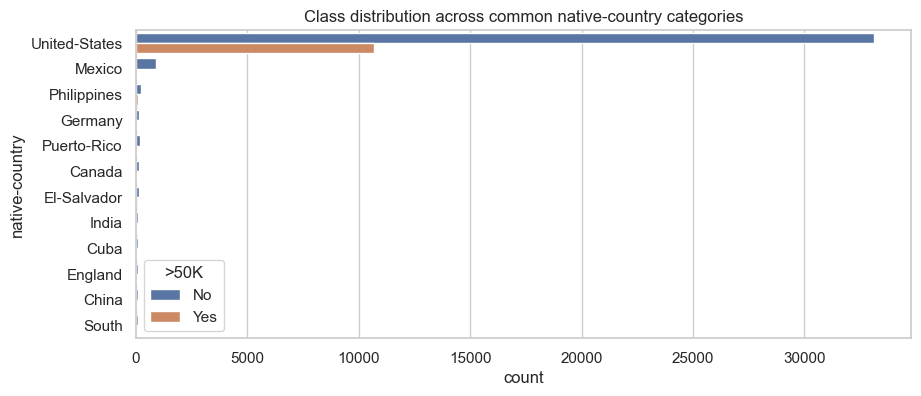

In [6]:
eda_df = X.copy()
eda_df["income_gt_50k"] = y

for col in [c for c in ["age", "education-num", "hours-per-week", "capital-gain"] if c in X.columns]:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.boxplot(data=eda_df, x="income_gt_50k", y=col, ax=ax)
    ax.set_xticklabels(["<=50K", ">50K"])
    ax.set_title(f"{col} by income group")
    plt.show()

for col in [c for c in ["education", "occupation", "native-country"] if c in X.columns]:
    top_levels = X[col].value_counts().head(12).index
    tmp = eda_df[eda_df[col].isin(top_levels)].copy()
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.countplot(data=tmp, y=col, hue="income_gt_50k", order=top_levels, ax=ax)
    ax.set_title(f"Class distribution across common {col} categories")
    ax.legend(title=">50K", labels=["No", "Yes"])
    plt.show()

## Train/validation/test split

A separate test set is kept aside for final comparison. Most model comparisons below use the validation set. Transformations are fitted only on the training portion through pipelines, which prevents information from the validation or test set from influencing preprocessing.

In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Validation:", X_valid.shape, "Test:", X_test.shape)
print("Validation target rate >50K:", round(y_valid.mean(), 3))

Train: (29304, 14) Validation: (9769, 14) Test: (9769, 14)
Validation target rate >50K: 0.239


## Utility functions for fair comparisons

A feature-engineering experiment should be judged against a baseline. The helper functions below collect common metrics, estimate the number of generated features when possible, and store results in a comparison table.

In [8]:
results = []

def get_num_features(model, X_sample):
    try:
        pre = model.named_steps.get("preprocess", None)
        if pre is not None:
            return len(pre.get_feature_names_out())
    except Exception:
        pass
    try:
        Xt = model[:-1].transform(X_sample.head(5))
        return Xt.shape[1]
    except Exception:
        return np.nan

def evaluate_classifier(model, X_tr, y_tr, X_val, y_val, name, model_label, note="", show_report=False):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_val)[:, 1]
    else:
        score = model.decision_function(X_val)

    row = {
        "feature_set": name,
        "model": model_label,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, score),
        "n_features": get_num_features(model, X_tr),
        "interpretability_note": note
    }
    results.append(row)

    if show_report:
        print(classification_report(y_val, pred, target_names=["<=50K", ">50K"]))
        ConfusionMatrixDisplay.from_predictions(y_val, pred, display_labels=["<=50K", ">50K"])
        plt.title(f"Confusion matrix — {name} / {model_label}")
        plt.show()

    return row

def show_results():
    df = pd.DataFrame(results).drop_duplicates(subset=["feature_set", "model"], keep="last")
    for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        df[col] = df[col].round(4)
    return df.sort_values("roc_auc", ascending=False).reset_index(drop=True)

## Baseline model with minimal feature processing

The baseline is not meant to be the final solution. It gives a reference point: numerical variables are median-imputed and scaled, categorical variables are imputed and one-hot encoded, and a logistic regression model is fitted. Logistic regression is a useful baseline because it is interpretable, fast, and sensitive to representation choices.

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7432
        >50K       0.57      0.85      0.68      2337

    accuracy                           0.81      9769
   macro avg       0.76      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



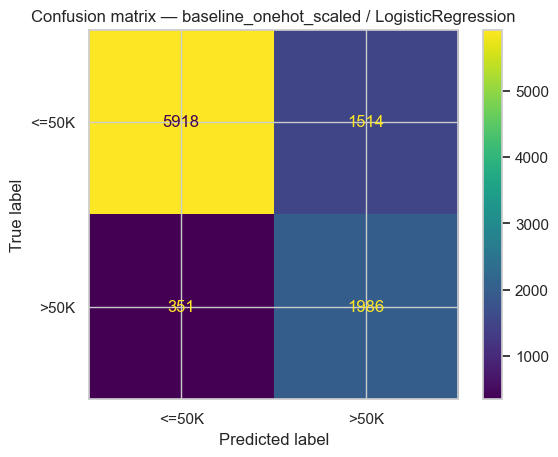

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...


In [9]:
numeric_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# scikit-learn renamed the OneHotEncoder argument from sparse to sparse_output.
# This helper keeps the notebook usable across common versions.
try:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_onehot = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", _ohe)
])

baseline_preprocess = ColumnTransformer([
    ("num", numeric_baseline, num_cols),
    ("cat", categorical_onehot, cat_cols)
])

logreg_baseline = Pipeline([
    ("preprocess", baseline_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    logreg_baseline, X_train, y_train, X_valid, y_valid,
    name="baseline_onehot_scaled",
    model_label="LogisticRegression",
    note="Interpretable linear baseline with one coefficient per encoded feature.",
    show_report=True
)

show_results()

### Reading a linear model through coefficients

One advantage of a one-hot encoded logistic-regression baseline is that each transformed feature receives a coefficient. A positive coefficient pushes the prediction toward the higher-income class, while a negative coefficient pushes it toward the lower-income class. These coefficients are not causal effects: they are model parameters learned under the chosen preprocessing, regularization, and correlations among features. Still, they are useful for checking whether the representation creates interpretable signals.

In [10]:
# Inspect the strongest positive and negative coefficients from the fitted logistic-regression baseline.
# Because numerical variables were scaled and categorical variables were one-hot encoded,
# coefficient magnitudes are more comparable than they would be on raw, unscaled columns.

logreg_baseline.fit(X_train, y_train)
feature_names = logreg_baseline.named_steps["preprocess"].get_feature_names_out()
coef = logreg_baseline.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef)
}).sort_values("coefficient")

print("Most negative coefficients: features pushing the model toward <=50K")
display(coef_df.head(12)[["feature", "coefficient"]])

print("Most positive coefficients: features pushing the model toward >50K")
display(coef_df.tail(12).sort_values("coefficient", ascending=False)[["feature", "coefficient"]])

Most negative coefficients: features pushing the model toward <=50K


,feature,coefficient
101,cat__native-country_Trinadad&Tobago,-1.473490
45,cat__occupation_Priv-house-serv,-1.346854
69,cat__native-country_Dominican-Republic,-1.219775
34,cat__marital-status_Never-married,-1.045558
67,cat__native-country_Columbia,-0.914582
41,cat__occupation_Farming-fishing,-0.881783
44,cat__occupation_Other-service,-0.760263
35,cat__marital-status_Separated,-0.741966
100,cat__native-country_Thailand,-0.673659
53,cat__relationship_Other-relative,-0.673355


Most positive coefficients: features pushing the model toward >50K


,feature,coefficient
3,num__capital-gain,2.293781
32,cat__marital-status_Married-civ-spouse,1.809241
31,cat__marital-status_Married-AF-spouse,1.698280
84,cat__native-country_Ireland,1.263550
72,cat__native-country_England,1.121401
56,cat__relationship_Wife,1.013903
104,cat__native-country_Yugoslavia,0.930156
64,cat__native-country_Cambodia,0.855673
40,cat__occupation_Exec-managerial,0.848457
93,cat__native-country_Philippines,0.768684


## Tree-based baseline

Tree-based models split features by thresholds and therefore do not need feature scaling in the same way as logistic regression, SVM, or KNN. They can capture nonlinearities and interactions more naturally. However, most scikit-learn tree models still require categorical variables to be converted to numbers. Here we use one-hot encoding for categorical variables and a random forest as the tree-based reference.

In [11]:
tree_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", categorical_onehot, cat_cols)
])

rf_baseline = Pipeline([
    ("preprocess", tree_preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=3,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE
    ))
])

evaluate_classifier(
    rf_baseline, X_train, y_train, X_valid, y_valid,
    name="baseline_onehot_no_scaling",
    model_label="RandomForest",
    note="Tree ensemble; scaling is not central, but categorical encoding is still required."
)

show_results()

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...


## Numerical transformation: log transform

Some numerical variables are highly right-skewed. In the Adult dataset, `capital-gain` and `capital-loss` often contain many zeros and a small number of large values. Linear models can struggle when a few extreme values dominate the fitted relationship. A `log1p` transform compresses large values while keeping zeros valid.

After running the comparison, check whether the log-transformed representation improves validation performance or mainly changes coefficient stability. A transformation can be valuable even when the metric change is modest if it makes the learned relationship less dominated by extreme observations.

Log-transform candidates: ['capital-gain', 'capital-loss', 'fnlwgt']


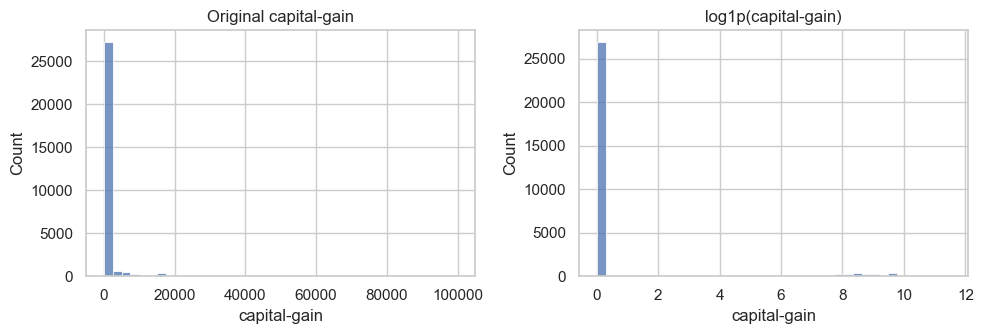

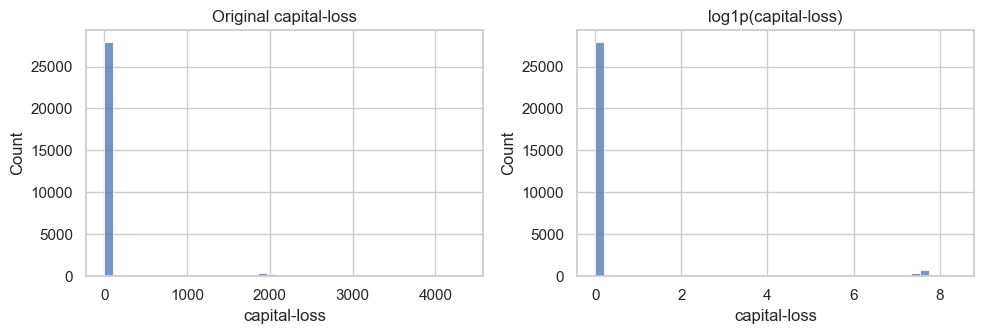

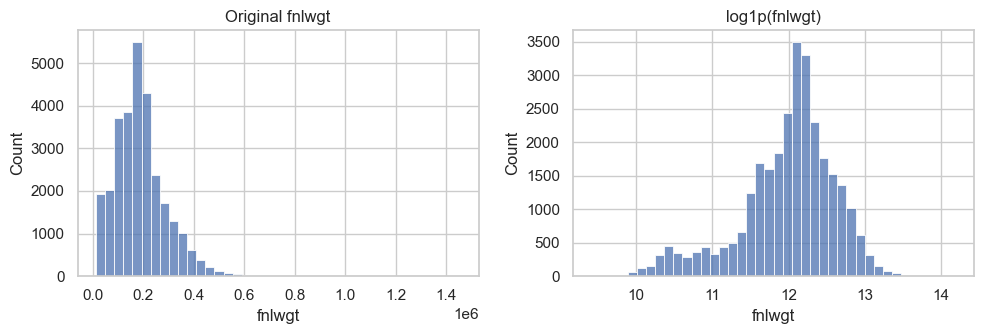

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
2,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...


In [12]:
skewed_positive_cols = [
    c for c in ["capital-gain", "capital-loss", "fnlwgt"] 
    if c in num_cols and (X_train[c].min(skipna=True) >= 0)
]
other_num_cols = [c for c in num_cols if c not in skewed_positive_cols]

print("Log-transform candidates:", skewed_positive_cols)

for col in skewed_positive_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    sns.histplot(X_train[col].dropna(), bins=40, ax=axes[0])
    axes[0].set_title(f"Original {col}")
    sns.histplot(np.log1p(X_train[col].dropna()), bins=40, ax=axes[1])
    axes[1].set_title(f"log1p({col})")
    plt.tight_layout()
    plt.show()

log_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

regular_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

log_preprocess = ColumnTransformer([
    ("log_num", log_num_pipe, skewed_positive_cols),
    ("num", regular_num_pipe, other_num_cols),
    ("cat", categorical_onehot, cat_cols)
])

log_model = Pipeline([
    ("preprocess", log_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    log_model, X_train, y_train, X_valid, y_valid,
    name="log_transform_skewed_numerics",
    model_label="LogisticRegression",
    note="Compresses long-tailed numerical variables before fitting a linear decision boundary."
)

show_results()

## Binning numerical variables

Binning converts a continuous variable into intervals. This can help when the relationship between a variable and the target is threshold-like rather than smoothly linear. The trade-off is information loss: once age is converted into intervals, the model no longer knows the exact age.

Equal-width binning creates intervals of the same numerical width, while quantile binning creates intervals with roughly similar numbers of observations. Quantile binning is often more stable when a variable is skewed.

In [13]:
class AgeHourBinner(BaseEstimator, TransformerMixin):
    '''Create interpretable bins for age and hours-per-week without using the target.'''
    def __init__(self, keep_original=True):
        self.keep_original = keep_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()
        out = pd.DataFrame(index=X_.index)

        if self.keep_original:
            for c in X_.columns:
                out[c] = X_[c]

        if "age" in X_.columns:
            out["age_group"] = pd.cut(
                X_["age"],
                bins=[0, 25, 35, 45, 55, 65, np.inf],
                labels=["<=25", "26-35", "36-45", "46-55", "56-65", "66+"]
            ).astype("object")

        if "hours-per-week" in X_.columns:
            out["hours_group"] = pd.cut(
                X_["hours-per-week"],
                bins=[0, 20, 35, 40, 50, 60, np.inf],
                labels=["<=20", "21-35", "36-40", "41-50", "51-60", "61+"]
            ).astype("object")
        return out

def make_binning_pipeline(keep_original):
    pre = Pipeline([
        ("binning", AgeHourBinner(keep_original=keep_original)),
        ("preprocess", ColumnTransformer([
            ("num", numeric_baseline, selector(dtype_include=np.number)),
            ("cat", categorical_onehot, selector(dtype_exclude=np.number))
        ]))
    ])
    return Pipeline([
        ("preprocess", pre),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
    ])

bin_only_model = make_binning_pipeline(keep_original=False)
raw_plus_bins_model = make_binning_pipeline(keep_original=True)

evaluate_classifier(
    bin_only_model, X_train, y_train, X_valid, y_valid,
    name="age_hours_binned_only",
    model_label="LogisticRegression",
    note="Uses interpretable intervals but discards exact continuous values."
)

evaluate_classifier(
    raw_plus_bins_model, X_train, y_train, X_valid, y_valid,
    name="raw_plus_age_hours_bins",
    model_label="LogisticRegression",
    note="Keeps exact values while adding threshold-like categorical signals."
)

show_results()

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
3,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
4,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


## One-hot encoding and dimensionality

One-hot encoding represents each category as a separate binary feature. It is appropriate for nominal variables where there is no natural ordering, such as occupation or workclass. It works well with linear models because each category receives its own coefficient.

The drawback is dimensionality. A categorical variable with many distinct values creates many sparse columns. Rare categories can lead to unstable estimates because the model sees few examples for those coefficients.

In [14]:
logreg_baseline.fit(X_train, y_train)
feature_names = logreg_baseline.named_steps["preprocess"].get_feature_names_out()
print("Number of original columns:", X_train.shape[1])
print("Number of encoded features after baseline preprocessing:", len(feature_names))

encoded_counts = pd.Series(feature_names).str.extract(r"^(.*?)__")[0].value_counts()
display(encoded_counts.to_frame("encoded_feature_count_by_transformer"))

print("Example one-hot features:")
for f in [f for f in feature_names if "cat__" in f][:20]:
    print("  ", f)

Number of original columns: 14
Number of encoded features after baseline preprocessing: 105


,encoded_feature_count_by_transformer
cat,99
num,6


Example one-hot features:
   cat__workclass_Federal-gov
   cat__workclass_Local-gov
   cat__workclass_Never-worked
   cat__workclass_Private
   cat__workclass_Self-emp-inc
   cat__workclass_Self-emp-not-inc
   cat__workclass_State-gov
   cat__workclass_Without-pay
   cat__education_10th
   cat__education_11th
   cat__education_12th
   cat__education_1st-4th
   cat__education_5th-6th
   cat__education_7th-8th
   cat__education_9th
   cat__education_Assoc-acdm
   cat__education_Assoc-voc
   cat__education_Bachelors
   cat__education_Doctorate
   cat__education_HS-grad


## Ordinal encoding

Ordinal encoding maps categories to integers. This is meaningful only when categories have an order. In the Adult dataset, `education-num` already provides an ordered numerical representation of education level. Blindly ordinal-encoding nominal variables such as occupation would create an artificial order where one occupation appears numerically larger than another.

The comparison below uses education-related representations to show why ordered information should be handled deliberately rather than mechanically.

In [15]:
education_cols = [c for c in ["education", "education-num"] if c in X.columns]
display(X_train[education_cols].drop_duplicates().sort_values("education-num").head(20))

cols_without_education_label = [c for c in X.columns if c != "education"]
num_wo = [c for c in num_cols if c in cols_without_education_label]
cat_wo = [c for c in cat_cols if c in cols_without_education_label]

edu_num_preprocess = ColumnTransformer([
    ("num", numeric_baseline, num_wo),
    ("cat", categorical_onehot, cat_wo)
])

edu_num_model = Pipeline([
    ("preprocess", edu_num_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    edu_num_model, X_train[cols_without_education_label], y_train,
    X_valid[cols_without_education_label], y_valid,
    name="education_num_without_education_label",
    model_label="LogisticRegression",
    note="Uses the ordered education-num representation and removes the nominal education label."
)

show_results()

,education,education-num
11677,Preschool,1.0
5668,1st-4th,2.0
5736,5th-6th,3.0
13802,7th-8th,4.0
2097,9th,5.0
1919,10th,6.0
31307,11th,7.0
1210,12th,8.0
23803,HS-grad,9.0
46557,Some-college,10.0


,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
3,education_num_without_education_label,LogisticRegression,0.8079,0.5656,0.8490,0.6789,0.9070,89,Uses the ordered education-num representation ...
4,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
5,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


## Frequency encoding

Frequency encoding replaces each category by how often it appears in the training data. It is useful for high-cardinality variables because it keeps one column instead of expanding into many dummy columns. However, it loses category identity: two categories with the same frequency become indistinguishable.

This encoder is fitted only on the training data. Frequencies for unseen validation or test categories are replaced with zero.

In [16]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Frequency-encode each incoming categorical column.

    ColumnTransformer often passes a NumPy array to custom transformers after
    imputation. Converting that array to a DataFrame gives integer column names.
    The implementation therefore uses f-strings for output names and keeps a
    robust record of incoming feature names for later inspection.
    """
    def __init__(self):
        self.maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = X.columns.to_numpy()
        n = len(X)
        self.maps_ = {
            col: X[col].value_counts(dropna=False).div(n).to_dict()
            for col in X.columns
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in X.columns:
            out[f"{col}_freq"] = (
                X[col]
                .map(self.maps_.get(col, {}))
                .fillna(0.0)
                .astype(float)
            )
        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array([f"{c}_freq" for c in input_features], dtype=object)

high_card_cols = cardinality[cardinality >= 10].index.tolist()
low_card_cols = [c for c in cat_cols if c not in high_card_cols]

print("High-cardinality categorical columns:", high_card_cols)
print("Lower-cardinality categorical columns:", low_card_cols)

freq_preprocess = ColumnTransformer([
    ("num", numeric_baseline, num_cols),
    ("low_card_ohe", categorical_onehot, low_card_cols),
    ("high_card_freq", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("freq", FrequencyEncoder())
    ]), high_card_cols)
])

freq_model = Pipeline([
    ("preprocess", freq_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    freq_model, X_train, y_train, X_valid, y_valid,
    name="frequency_encoding_high_cardinality",
    model_label="LogisticRegression",
    note="Reduces dimensionality for high-cardinality variables but loses category identity."
)

show_results()

High-cardinality categorical columns: ['native-country', 'education', 'occupation']
Lower-cardinality categorical columns: ['workclass', 'marital-status', 'relationship', 'race', 'sex']


,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
3,education_num_without_education_label,LogisticRegression,0.8079,0.5656,0.8490,0.6789,0.9070,89,Uses the ordered education-num representation ...
4,frequency_encoding_high_cardinality,LogisticRegression,0.8002,0.5538,0.8477,0.6699,0.9017,37,Reduces dimensionality for high-cardinality va...
5,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
6,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


## Target encoding with leakage control

Target encoding replaces a category with the average target value for that category. It can be powerful because it directly summarizes how a category relates to the target. It is also dangerous: if category-target statistics are computed using validation or test data, the model receives information it should not have.

The custom transformer below computes smoothed category means from the training data only. Smoothing shrinks rare-category estimates toward the global mean so that a category observed only a few times does not receive an extreme value. For rigorous model selection, target encoding should be nested inside cross-validation or implemented out-of-fold. Here it is used within a train/validation pipeline for demonstration, with the validation set kept untouched during fitting.

In [17]:
class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):
    """Smoothed target encoder for categorical columns.

    The encoder is fitted inside the training pipeline, so category-target
    averages are estimated from the training data only. Unknown validation/test
    categories are assigned the global training target mean.
    """
    def __init__(self, smoothing=20.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X).copy().reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        self.feature_names_in_ = X.columns.to_numpy()
        self.global_mean_ = float(y.mean())
        self.maps_ = {}

        for col in X.columns:
            stats = (
                pd.DataFrame({"x": X[col], "y": y})
                .groupby("x")["y"]
                .agg(["mean", "count"])
            )
            smooth = (
                stats["count"] * stats["mean"]
                + self.smoothing * self.global_mean_
            ) / (stats["count"] + self.smoothing)
            self.maps_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in X.columns:
            out[f"{col}_te"] = (
                X[col]
                .map(self.maps_.get(col, {}))
                .fillna(self.global_mean_)
                .astype(float)
            )
        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array([f"{c}_te" for c in input_features], dtype=object)

target_preprocess = ColumnTransformer([
    ("num", numeric_baseline, num_cols),
    ("low_card_ohe", categorical_onehot, low_card_cols),
    ("high_card_target", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target", SmoothedTargetEncoder(smoothing=30.0))
    ]), high_card_cols)
])

target_model = Pipeline([
    ("preprocess", target_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    target_model, X_train, y_train, X_valid, y_valid,
    name="smoothed_target_encoding_high_cardinality",
    model_label="LogisticRegression",
    note="Compact and predictive for high-cardinality variables, but must be fitted without validation/test leakage."
)

show_results()

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
3,education_num_without_education_label,LogisticRegression,0.8079,0.5656,0.8490,0.6789,0.9070,89,Uses the ordered education-num representation ...
4,smoothed_target_encoding_high_cardinality,LogisticRegression,0.8061,0.5632,0.8442,0.6757,0.9060,37,Compact and predictive for high-cardinality va...
5,frequency_encoding_high_cardinality,LogisticRegression,0.8002,0.5538,0.8477,0.6699,0.9017,37,Reduces dimensionality for high-cardinality va...
6,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
7,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


## Interaction features

An interaction means the effect of one variable depends on another. Linear models cannot automatically express interactions unless we create them. For example, the relationship between weekly working hours and income may depend on education level or age. Tree models can capture some interactions through repeated splits, but linear models need explicit interaction columns.

Interactions can help, but they also increase dimensionality and overfitting risk. It is better to add a small number of motivated interactions than to blindly generate all possible combinations.

In [18]:
class SelectedInteractions(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()
        out = pd.DataFrame(index=X_.index)

        if {"education-num", "hours-per-week"}.issubset(X_.columns):
            out["education_num_x_hours"] = X_["education-num"] * X_["hours-per-week"]

        if {"age", "hours-per-week"}.issubset(X_.columns):
            out["age_x_hours"] = X_["age"] * X_["hours-per-week"]

        if "capital-gain" in X_.columns:
            out["has_capital_gain"] = (X_["capital-gain"] > 0).astype(int)

        if out.shape[1] == 0:
            out["no_interaction_created"] = 0
        return out

interaction_preprocess = ColumnTransformer([
    ("num", numeric_baseline, num_cols),
    ("cat", categorical_onehot, cat_cols),
    ("interactions", Pipeline([
        ("creator", SelectedInteractions()),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), X.columns.tolist())
])

interaction_model = Pipeline([
    ("preprocess", interaction_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    interaction_model, X_train, y_train, X_valid, y_valid,
    name="selected_numerical_interactions",
    model_label="LogisticRegression",
    note="Adds motivated interactions that a linear model cannot express on its own."
)

show_results()

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,selected_numerical_interactions,LogisticRegression,0.8115,0.5713,0.8507,0.6835,0.9098,108,Adds motivated interactions that a linear mode...
3,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
4,education_num_without_education_label,LogisticRegression,0.8079,0.5656,0.8490,0.6789,0.9070,89,Uses the ordered education-num representation ...
5,smoothed_target_encoding_high_cardinality,LogisticRegression,0.8061,0.5632,0.8442,0.6757,0.9060,37,Compact and predictive for high-cardinality va...
6,frequency_encoding_high_cardinality,LogisticRegression,0.8002,0.5538,0.8477,0.6699,0.9017,37,Reduces dimensionality for high-cardinality va...
7,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
8,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


## Feature scaling: model-specific importance

Scaling changes the numerical range of features. It is important for gradient-based models and distance-based models such as logistic regression, SVM, KNN, and neural networks. If one feature has values in thousands and another ranges from 0 to 1, the larger-scale feature can dominate optimization or distance computation.

Tree models are much less sensitive to scaling because they use threshold splits. The same preprocessing rule is therefore not equally important for every model family.

In [19]:
numeric_no_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

no_scale_preprocess = ColumnTransformer([
    ("num", numeric_no_scale, num_cols),
    ("cat", categorical_onehot, cat_cols)
])

logreg_no_scale = Pipeline([
    ("preprocess", no_scale_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

evaluate_classifier(
    logreg_no_scale, X_train, y_train, X_valid, y_valid,
    name="onehot_without_numeric_scaling",
    model_label="LogisticRegression",
    note="Shows whether optimization and coefficients are affected by leaving numerical scales unchanged."
)

knn_scaled = Pipeline([
    ("preprocess", baseline_preprocess),
    ("model", KNeighborsClassifier(n_neighbors=25))
])

knn_no_scale = Pipeline([
    ("preprocess", no_scale_preprocess),
    ("model", KNeighborsClassifier(n_neighbors=25))
])

evaluate_classifier(
    knn_scaled, X_train, y_train, X_valid, y_valid,
    name="onehot_scaled",
    model_label="KNN",
    note="Distance-based model; scaling should matter because distances combine all numerical dimensions."
)

evaluate_classifier(
    knn_no_scale, X_train, y_train, X_valid, y_valid,
    name="onehot_without_numeric_scaling",
    model_label="KNN",
    note="Distance-based model without scaling; large-scale variables can dominate distances."
)

show_results()

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,selected_numerical_interactions,LogisticRegression,0.8115,0.5713,0.8507,0.6835,0.9098,108,Adds motivated interactions that a linear mode...
3,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
4,education_num_without_education_label,LogisticRegression,0.8079,0.5656,0.8490,0.6789,0.9070,89,Uses the ordered education-num representation ...
5,smoothed_target_encoding_high_cardinality,LogisticRegression,0.8061,0.5632,0.8442,0.6757,0.9060,37,Compact and predictive for high-cardinality va...
6,frequency_encoding_high_cardinality,LogisticRegression,0.8002,0.5538,0.8477,0.6699,0.9017,37,Reduces dimensionality for high-cardinality va...
7,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
8,onehot_scaled,KNN,0.8428,0.7016,0.5965,0.6448,0.8961,105,Distance-based model; scaling should matter be...
9,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


## High-cardinality categorical variables

A high-cardinality categorical feature has many distinct values. One-hot encoding preserves category identity but creates many sparse columns. Frequency encoding is compact but less expressive. Target encoding can be powerful but must be leakage-aware.

After running the comparison table, inspect whether the compact encodings reduce the number of features enough to justify any change in validation performance.

In [20]:
encoding_comparison = show_results()
display(
    encoding_comparison[
        encoding_comparison["feature_set"].isin([
            "baseline_onehot_scaled",
            "frequency_encoding_high_cardinality",
            "smoothed_target_encoding_high_cardinality"
        ])
    ][["feature_set", "model", "roc_auc", "f1", "n_features", "interpretability_note"]]
)

,feature_set,model,roc_auc,f1,n_features,interpretability_note
3,baseline_onehot_scaled,LogisticRegression,0.9071,0.6805,105,Interpretable linear baseline with one coeffic...
5,smoothed_target_encoding_high_cardinality,LogisticRegression,0.9060,0.6757,37,Compact and predictive for high-cardinality va...
6,frequency_encoding_high_cardinality,LogisticRegression,0.9017,0.6699,37,Reduces dimensionality for high-cardinality va...


## Model comparison across feature sets

The table below compares representation choices using the same validation split. A small metric difference should not be overinterpreted from one split; the goal is to understand how each representation changes dimensionality, assumptions, and interpretability.

,feature_set,model,accuracy,precision,recall,f1,roc_auc,n_features,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,0.8299,0.6032,0.8442,0.7036,0.9180,105,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,0.8153,0.5773,0.8515,0.6881,0.9128,117,Keeps exact values while adding threshold-like...
2,selected_numerical_interactions,LogisticRegression,0.8115,0.5713,0.8507,0.6835,0.9098,108,Adds motivated interactions that a linear mode...
3,baseline_onehot_scaled,LogisticRegression,0.8091,0.5674,0.8498,0.6805,0.9071,105,Interpretable linear baseline with one coeffic...
4,education_num_without_education_label,LogisticRegression,0.8079,0.5656,0.8490,0.6789,0.9070,89,Uses the ordered education-num representation ...
5,smoothed_target_encoding_high_cardinality,LogisticRegression,0.8061,0.5632,0.8442,0.6757,0.9060,37,Compact and predictive for high-cardinality va...
6,frequency_encoding_high_cardinality,LogisticRegression,0.8002,0.5538,0.8477,0.6699,0.9017,37,Reduces dimensionality for high-cardinality va...
7,log_transform_skewed_numerics,LogisticRegression,0.8029,0.5583,0.8447,0.6722,0.9008,105,Compresses long-tailed numerical variables bef...
8,onehot_scaled,KNN,0.8428,0.7016,0.5965,0.6448,0.8961,105,Distance-based model; scaling should matter be...
9,age_hours_binned_only,LogisticRegression,0.6312,0.3764,0.8250,0.5170,0.7578,12,Uses interpretable intervals but discards exac...


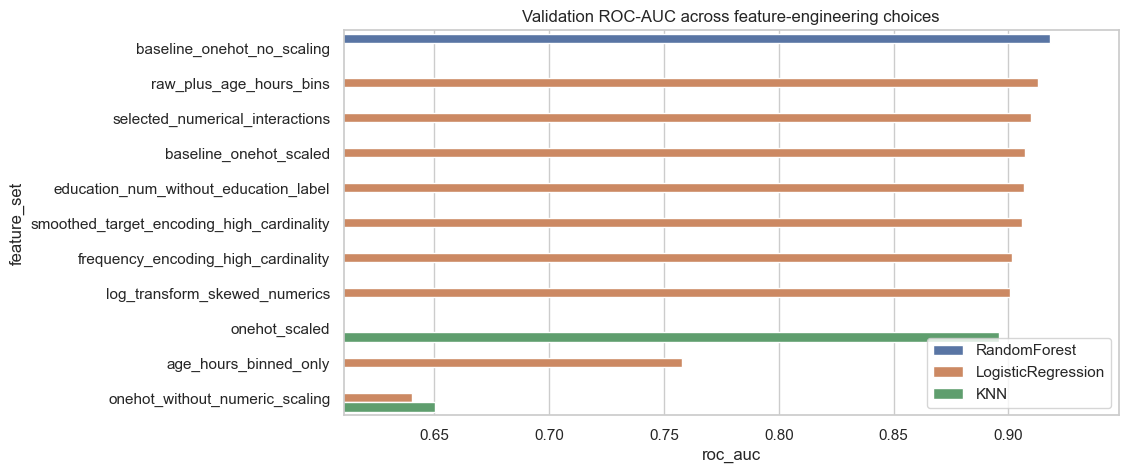

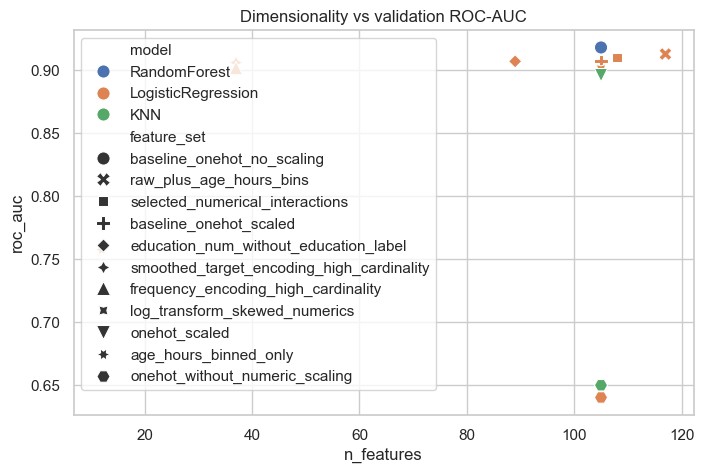

In [21]:
comparison = show_results()
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = comparison.copy()
sns.barplot(data=plot_df, y="feature_set", x="roc_auc", hue="model", ax=ax)
ax.set_title("Validation ROC-AUC across feature-engineering choices")
ax.set_xlim(max(0.0, plot_df["roc_auc"].min() - 0.03), min(1.0, plot_df["roc_auc"].max() + 0.03))
plt.legend(loc="lower right")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=plot_df, x="n_features", y="roc_auc", hue="model", style="feature_set", s=90, ax=ax)
ax.set_title("Dimensionality vs validation ROC-AUC")
plt.show()

### Interpreting metric changes relative to the baseline

The comparison table is easier to read when every experiment is expressed as a change from the baseline. A small validation gain may not justify a much more complex representation, while a similar score with fewer features can still be valuable if it improves simplicity or robustness. The table below is intentionally output-dependent: after execution, use it to judge whether each engineered representation gives a meaningful benefit or only a cosmetic change.

,feature_set,model,n_features,roc_auc,delta_roc_auc,f1,delta_f1,interpretability_note
0,baseline_onehot_no_scaling,RandomForest,105,0.9180,0.0109,0.7036,0.0231,"Tree ensemble; scaling is not central, but cat..."
1,raw_plus_age_hours_bins,LogisticRegression,117,0.9128,0.0057,0.6881,0.0076,Keeps exact values while adding threshold-like...
2,selected_numerical_interactions,LogisticRegression,108,0.9098,0.0027,0.6835,0.0030,Adds motivated interactions that a linear mode...
3,baseline_onehot_scaled,LogisticRegression,105,0.9071,0.0000,0.6805,0.0000,Interpretable linear baseline with one coeffic...
4,education_num_without_education_label,LogisticRegression,89,0.9070,-0.0001,0.6789,-0.0016,Uses the ordered education-num representation ...
5,smoothed_target_encoding_high_cardinality,LogisticRegression,37,0.9060,-0.0011,0.6757,-0.0048,Compact and predictive for high-cardinality va...
6,frequency_encoding_high_cardinality,LogisticRegression,37,0.9017,-0.0054,0.6699,-0.0106,Reduces dimensionality for high-cardinality va...
7,log_transform_skewed_numerics,LogisticRegression,105,0.9008,-0.0063,0.6722,-0.0083,Compresses long-tailed numerical variables bef...
8,onehot_scaled,KNN,105,0.8961,-0.0110,0.6448,-0.0357,Distance-based model; scaling should matter be...
9,age_hours_binned_only,LogisticRegression,12,0.7578,-0.1493,0.5170,-0.1635,Uses interpretable intervals but discards exac...


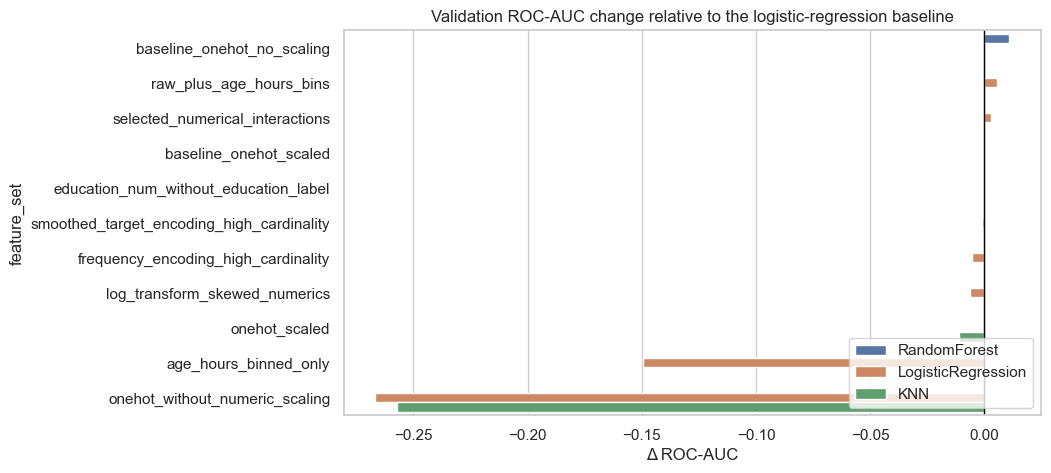

In [22]:
comparison = show_results()
baseline_mask = (comparison["feature_set"] == "baseline_onehot_scaled") & (comparison["model"] == "LogisticRegression")
baseline_ref = comparison.loc[baseline_mask].iloc[0]

delta_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
delta_table = comparison.copy()
for col in delta_cols:
    delta_table[f"delta_{col}"] = delta_table[col] - baseline_ref[col]

display(
    delta_table[[
        "feature_set", "model", "n_features", "roc_auc", "delta_roc_auc", "f1", "delta_f1", "interpretability_note"
    ]].sort_values("delta_roc_auc", ascending=False).round(4)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=delta_table, y="feature_set", x="delta_roc_auc", hue="model", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Validation ROC-AUC change relative to the logistic-regression baseline")
ax.set_xlabel("Δ ROC-AUC")
plt.legend(loc="lower right")
plt.show()

## Permutation importance

Permutation importance asks: if we randomly shuffle one feature, how much does model performance drop? A feature is important when disturbing it harms the trained model. This measures model dependence, not causality.

For one-hot encoded pipelines, permutation importance at the original-column level is often easier to interpret than importance for every dummy variable. The code below permutes original input columns on the validation set and measures the change in ROC-AUC.

,feature,importance_mean,importance_std
5,marital-status,0.142269,0.005502
4,education-num,0.036460,0.001697
10,capital-gain,0.035814,0.001111
6,occupation,0.016047,0.001119
7,relationship,0.010939,0.000745
12,hours-per-week,0.010875,0.000931
0,age,0.008284,0.000262
9,sex,0.006087,0.000864
11,capital-loss,0.004910,0.000613
1,workclass,0.002440,0.000241


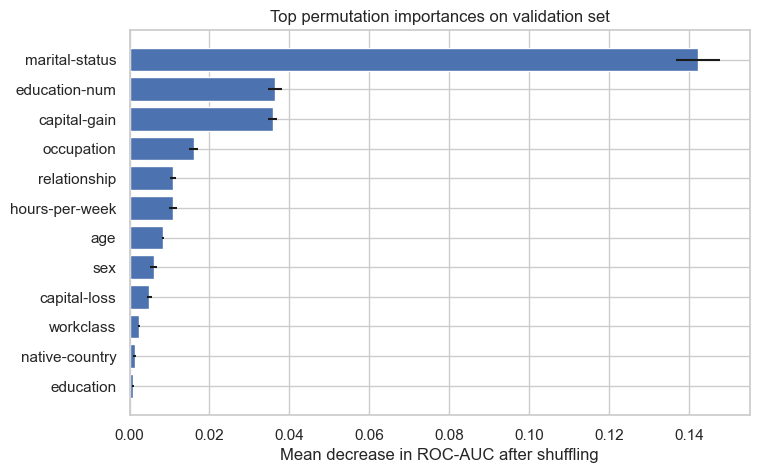

In [23]:
strong_model = logreg_baseline
strong_model.fit(X_train, y_train)

perm = permutation_importance(
    strong_model, X_valid, y_valid,
    scoring="roc_auc",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_perm = perm_df.head(12).sort_values("importance_mean")
ax.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
ax.set_title("Top permutation importances on validation set")
ax.set_xlabel("Mean decrease in ROC-AUC after shuffling")
plt.show()

### Interpreting permutation importance carefully

Permutation importance can be affected by correlated or redundant features. If two columns carry similar information, shuffling one may show limited importance because the other still compensates. Importance also describes the fitted model, not the real-world cause of income. A socially sensitive variable can be predictive because of historical or structural patterns, but that does not make it appropriate for decision-making.

## Threshold analysis: the model score is not the final decision rule

Classification models usually produce a probability or score, and the default class label comes from a threshold of 0.5. That threshold is not always the right operational choice. If false positives and false negatives have different costs, a practitioner may prefer a threshold that increases recall at the cost of precision, or vice versa. This experiment uses the best validation candidate by ROC-AUC and shows how precision, recall, and F1 change across thresholds.

Best validation candidate used for threshold analysis: baseline_onehot_no_scaling / RandomForest


,threshold,precision,recall,f1
0,0.000,0.239,1.000,0.386
877,0.008,0.266,1.000,0.420
1754,0.024,0.295,0.998,0.455
2631,0.053,0.332,0.997,0.498
3508,0.107,0.375,0.986,0.543
4385,0.191,0.430,0.969,0.595
5262,0.313,0.500,0.940,0.653
6139,0.453,0.581,0.874,0.698
7016,0.597,0.669,0.756,0.710
7893,0.724,0.782,0.588,0.671


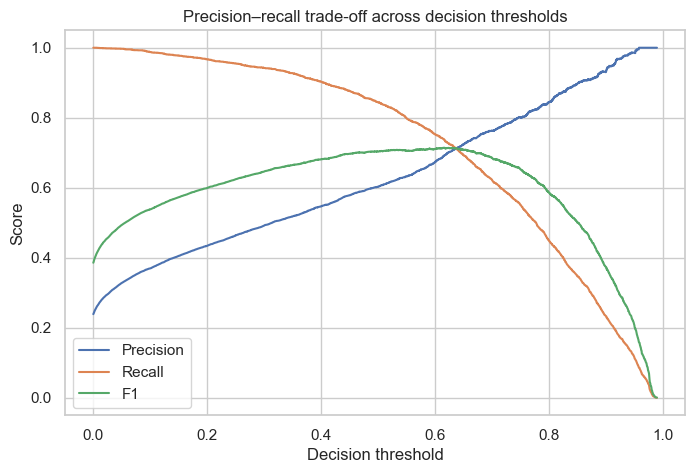

Threshold with highest validation F1:


,threshold,precision,recall,f1
7167,0.6168,0.6931,0.7373,0.7145


In [24]:
from sklearn.metrics import precision_recall_curve

candidate_models = {
    "baseline_onehot_scaled / LogisticRegression": logreg_baseline,
    "baseline_onehot_no_scaling / RandomForest": rf_baseline,
    "log_transform_skewed_numerics / LogisticRegression": log_model,
    "raw_plus_age_hours_bins / LogisticRegression": raw_plus_bins_model,
    "frequency_encoding_high_cardinality / LogisticRegression": freq_model,
    "smoothed_target_encoding_high_cardinality / LogisticRegression": target_model,
    "selected_numerical_interactions / LogisticRegression": interaction_model,
    "onehot_scaled / KNN": knn_scaled,
    "onehot_without_numeric_scaling / KNN": knn_no_scale,
    "onehot_without_numeric_scaling / LogisticRegression": logreg_no_scale,
}

comparison = show_results().copy()
comparison["candidate_key"] = comparison["feature_set"] + " / " + comparison["model"]
available_for_threshold = comparison[comparison["candidate_key"].isin(candidate_models)]
best_row = available_for_threshold.iloc[0]
best_key = best_row["candidate_key"]
best_model_for_threshold = candidate_models[best_key]
print("Best validation candidate used for threshold analysis:", best_key)

best_model_for_threshold.fit(X_train, y_train)
scores = best_model_for_threshold.predict_proba(X_valid)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_valid, scores)
# The last precision/recall pair has no associated threshold.
f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_values
})

display(threshold_df.iloc[np.linspace(0, len(threshold_df)-1, 12, dtype=int)].round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision–recall trade-off across decision thresholds")
ax.legend()
plt.show()

best_threshold_row = threshold_df.iloc[threshold_df["f1"].idxmax()]
print("Threshold with highest validation F1:")
display(best_threshold_row.to_frame().T.round(4))

## Final test-set check for selected models

The validation set guided comparison. The test set should be used sparingly, after selecting a small number of candidates. Here we evaluate the baseline linear model, the tree baseline, and two engineered logistic models. If you modify the notebook, avoid repeatedly optimizing on the test set.

In [25]:
test_candidates = {
    "baseline_onehot_scaled / LogisticRegression": logreg_baseline,
    "baseline_onehot_no_scaling / RandomForest": rf_baseline,
    "selected_numerical_interactions / LogisticRegression": interaction_model,
    "smoothed_target_encoding_high_cardinality / LogisticRegression": target_model
}

test_rows = []
for name, model in test_candidates.items():
    model.fit(X_train_full, y_train_full)
    pred = model.predict(X_test)
    score = model.predict_proba(X_test)[:, 1]
    test_rows.append({
        "candidate": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score)
    })

test_results = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False)
display(test_results.round(4))

print(
    "Use this table as a final sanity check, not as a new tuning set. "
    "If the validation winner drops strongly on the test set, the validation comparison may have been noisy."
)

,candidate,accuracy,precision,recall,f1,roc_auc
1,baseline_onehot_no_scaling / RandomForest,0.8279,0.6005,0.8396,0.7002,0.9169
2,selected_numerical_interactions / LogisticRegr...,0.8107,0.5706,0.8447,0.6812,0.9083
0,baseline_onehot_scaled / LogisticRegression,0.8069,0.5647,0.8435,0.6765,0.9044
3,smoothed_target_encoding_high_cardinality / Lo...,0.8092,0.5685,0.8417,0.6786,0.9034


Use this table as a final sanity check, not as a new tuning set. If the validation winner drops strongly on the test set, the validation comparison may have been noisy.


## Interpretation and practical lessons

The main lesson is that feature engineering changes the learning problem. Linear models often benefit from scaling, log transformations, one-hot encoding, and explicitly created interactions because these choices make relationships easier to represent with a linear decision boundary. Tree-based models can absorb nonlinearities and threshold effects more naturally, but still need categorical variables converted into a usable form unless the chosen model supports categorical features natively.

Encoding choices also change dimensionality. One-hot encoding keeps category identity but may produce many sparse columns. Frequency encoding is compact but loses identity. Target encoding can be strong for high-cardinality variables, but it is one of the easiest places to introduce leakage.

After running the notebook, compare whether any engineered feature set improves validation performance enough to justify the added complexity. Also inspect whether a simpler representation gives nearly the same performance with fewer features or clearer interpretation.

The added coefficient, delta-from-baseline, and threshold analyses are designed to turn the output tables into decisions. They help separate three questions that are often mixed together: whether a representation improves ranking performance, whether it changes the final classification trade-off, and whether the representation remains understandable enough to justify using it.

## Limitations

Feature engineering is dataset-dependent. A transformation that helps on Adult Income may not help on another dataset. Some variables in this dataset encode social and demographic information, so predictive importance should not be treated as ethical justification for automated decisions.

Permutation importance and model coefficients describe model behavior, not causality. Target encoding can overfit if not implemented carefully. Interaction features can quickly expand dimensionality. Finally, a single train/validation/test split gives useful evidence but does not fully establish robustness; repeated cross-validation is preferable for stronger conclusions.

## What we learned

Machine learning models learn from representations, not raw reality. Different algorithms benefit from different preprocessing choices. Feature engineering can improve performance, interpretability, or robustness, but more features are not always better. Leakage-aware pipelines are essential because transformations must be learned from training data only. The best feature set is not merely the one with the highest score; it should also be judged by complexity, stability, and practical meaning.

## Possible extensions

Natural next steps include automated feature engineering with Featuretools, CatBoost with native categorical handling, SHAP-based interpretation, fairness analysis, model calibration, repeated cross-validation, and comparison with another mixed-type dataset such as Titanic, Bank Marketing, or Ames Housing.